In [5]:
# ============================================================
# SurvivalPoleMDS クラス定義（Paper 1 静的分析・完全対応版）
# ============================================================
# 論文「Pole-augmented multidimensional scaling for descriptive
# descriptive survival-based visualization」の
# 静的分析を、そのまま追えるように整理した notebook 用クラス。
# 特定の応用分野に依存しない汎用実装である。
#
# この notebook での論文対応は次のとおり。
#   Table 1  : Distances from each covariate to the event pole (Monopolar)
#   Table 2  : Cox proportional hazards model
#   Figure 1 : Monopolar configuration
#   Table 3  : Bipolar configuration: distances to two poles + Delta
#   Figure 2 : Bipolar configuration
#   Table 4  : Monopolar with Cox residual added: distances
#   Table 5  : Bipolar with Cox residual added: distances to two poles + Delta
#   Figure 3 : Monopolar (left) and bipolar (right), Cox residual added
#
# 全体フロー:
#   1. __init__                       : データ受け取り, 3種類の残差計算
#   2. fit_all                        : 4モデル構成で sim/dist/coords を計算
#   3. build_monopolar_cmds_distance_table : 単極構成の 2D CMDS 座標距離表
#   4. build_cox_table                     : Cox 回帰の係数, ハザード比, p 値表
#   5. build_bipolar_cmds_distance_table   : 双極/Cox残差付き双極の 2D CMDS 座標距離・Delta 表
#   6. print_distance_table                : 距離テーブルを警告ブロック付きで画面表示
#   7. save_distance_table_to_csv          : 距離テーブルを警告ブロック付きで CSV 保存
#   8. print_diagnostics                   : 相関・距離・座標などの補助出力 (両方の距離を比較)
#   9. save_figures                        : 単極/双極/フルの図を PNG 保存
#
# 論文の表番号や CSV ファイル名はクラスでは持たず、ドライバ側で管理する.
#
# 重要: 距離の区別について
#   このクラスでは, 各 configuration ごとに 2 種類の距離行列を保持する.
#   - dist        : 入力距離行列 D = (1-r)^alpha (CMDS の入力)
#   - coord_dist  : 2 次元座標距離 D_hat = ||x_a - x_b|| (CMDS 出力後の射影距離)
#   論文の表 (Table 1, 3, 4, 5) に載せるのは coord_dist (2 次元座標距離) である.
#   入力距離 D は配置に依らず同じ値だが, 座標距離は configuration ごとに異なる.
#   両者は CMDS の 2 次元射影による情報損失のため, 一般に一致しない.
#   診断出力 (print_diagnostics) では両方を並べて表示し, 警告も付ける.
# ============================================================

# --- ライブラリの読み込み ---
# numpy: 数値計算の基本ライブラリ. 配列演算・線形代数の中核
import numpy as np

# pandas: 表形式データ（DataFrame）の操作
import pandas as pd

# matplotlib: 作図ライブラリ
import matplotlib
import matplotlib.pyplot as plt

# lifelines: 生存時間解析のライブラリ
#   NelsonAalenFitter : 累積ハザード Λ(t) の推定
#   KaplanMeierFitter : 生存関数 S(t) の推定
#   CoxPHFitter       : Cox 比例ハザード回帰
from lifelines import NelsonAalenFitter, KaplanMeierFitter, CoxPHFitter

# tabulate: 表を整形して標準出力に表示する
from tabulate import tabulate


class SurvivalPoleMDS:
    """極拡張 CMDS による生存分析データの静的可視化（汎用版）.

    任意の生存時間データセットに対して、イベント極と非イベント極を
    CMDS 空間に埋め込む可視化を行う. 残差計算、4 モデル構成の MDS、
    表と図の出力までを一括管理する.

    Paper 1 で提案された MDS による生存解析可視化の汎用実装.
    具体的なデータセット名やラベル名は __init__ 引数として
    外から与える.
    """

    # ============================================================
    # 距離取り違え防止のための警告文字列（クラス定数）
    # ============================================================
    # 距離行列・距離テーブルを返すメソッドが呼ばれるたびに,
    # 「これがどちらの距離か」を必ず print して人間に伝える.
    #
    # 入力距離 D = (1 - r_ab)^alpha : 配置に依らず, 相関値だけで決まる
    # 2D CMDS 座標距離 ||x_a - x_b|| : 2 次元配置上のユークリッド距離.
    #                                  configuration ごとに異なる.
    # 両者は CMDS の 2 次元射影による情報損失のため一般に一致しない.
    # この警告は print_diagnostics, build_*_cmds_distance_table,
    # get_*_distance_matrix 等から呼ばれる.

    _WARN_INPUT_DISTANCE = (
        "\n\n\n"
        "############################################################\n"
        "##                                                        ##\n"
        "##  WARNING about the values shown BELOW:                 ##\n"
        "##                                                        ##\n"
        "##  The values are the INPUT distance D given to CMDS,    ##\n"
        "##  D_ab = (1 - r_ab) ^ alpha.                            ##\n"
        "##  This is NOT the 2D coordinate distance                ##\n"
        "##  ||x_a - x_b|| in the CMDS configuration.              ##\n"
        "##                                                        ##\n"
        "##  The following values are the INPUT distance D.        ##\n"
        "##                                                        ##\n"
        "↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓"
    )

    _WARN_CMDS_COORD_DISTANCE = (
        "\n\n\n"
        "############################################################\n"
        "##                                                        ##\n"
        "##  WARNING about the values shown BELOW:                 ##\n"
        "##                                                        ##\n"
        "##  The values are 2D CMDS COORDINATE distances           ##\n"
        "##  ||x_a - x_b|| in the two-dimensional CMDS             ##\n"
        "##  configuration. They are NOT the input distance        ##\n"
        "##  D = (1 - r)^alpha. CMDS approximates D by 2D coords   ##\n"
        "##  with some loss; the two are not equal in general.     ##\n"
        "##                                                        ##\n"
        "##  The following values are 2D CMDS coordinate           ##\n"
        "##  distances ||x_a - x_b||.                              ##\n"
        "##                                                        ##\n"
        "↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓"
    )

    # ============================================================
    # 距離変換指数（論文 Method 3.3 — Distance transform）
    # ============================================================
    # 論文 Method 3.3 の距離変換式:
    #   共変量間      : d_ij = √(1-s_ij)       = (1-s)^0.5
    #   共変量–極間   : d_ij = (1-s_ij)^3     = (1-s)^3.0
    #   極間          : d_ij = (1-s_ij)^(1/4) = (1-s)^0.25
    #
    # これらの指数は、論文では表示の見せ方を調整する calibration choices
    # として位置づける。
    #
    # 注意:
    # 以前は COV_COV, COV_POLE, POLE_POLE をクラス定数として置いていたが、
    # 本版では __init__ の引数 cov_cov, cov_pole, pole_pole に既定値を直接書く。
    # そのため、通常は何も指定しなくても同じ数値で動き、必要な場合だけ
    # ドライバセルから指数を上書きできる。

    # ============================================================
    # 初期化
    # ============================================================
    def __init__(self, df, covariates, time_col, event_col, tau,
                 event_pole, nonevent_pole,
                 cox_resid_name='Cox residual',
                 dataset_name='Dataset',
                 display_names=None,
                 cov_cov=0.5,
                 cov_pole=3.0,
                 pole_pole=0.25):
        """初期化と 3 種類の残差計算.

        論文 Method 3.1 (Pole construction) と Method 3.2 (Cox residual)
        で定義される残差を全てここで計算して self に保持する.

        Parameters
        ----------
        df              : pandas.DataFrame, shape (N, ...)
            入力データ. 生存時間・イベント・共変量の列を持つ
        covariates      : list[str]
            共変量の列名リスト
        time_col        : str
            生存時間列の名前
        event_col       : str
            イベント列の名前
        tau             : int or float
            観測打ち切り時点（Pseudo-value 評価時点）
        event_pole      : str
            イベント極のラベル名（例: 'Event', 'Death', 'Failure', 'Relapse'）
        nonevent_pole   : str
            非イベント極のラベル名（例: 'Non-event', 'Survival', 'No-failure'）
        cox_resid_name  : str, default 'Cox residual'
            Cox 残差（共変量として追加）のラベル名
        dataset_name    : str, default 'Dataset'
            データセット名（記述統計・図タイトルの接頭辞）
        display_names   : dict[str, str] or None
            変数の内部名 → 表示名のマッピング. None なら恒等
        cov_cov         : float, default 0.5
            共変量–共変量ペアの距離変換指数
        cov_pole        : float, default 3.0
            共変量–極ペアの距離変換指数
        pole_pole       : float, default 0.25
            極–極ペアの距離変換指数
        """
        # 入力データをインスタンスに保持
        # self.df: pandas.DataFrame. 入力データの参照
        self.df = df
        # self.covariates: list[str]. 共変量の列名リスト
        self.covariates = covariates
        # self.time_col, self.event_col: str. 時間・イベント列名
        self.time_col = time_col
        self.event_col = event_col
        # self.tau: float. 観測打ち切り時点
        self.tau = tau
        # self.N: int. サンプルサイズ
        self.N = len(df)

        # --- 入力列とラベル名の簡易チェック ---
        # ここで止めることで、後段の相関計算や作図で原因不明のエラーになるのを防ぐ。
        required_columns = set(covariates + [time_col, event_col])
        missing_columns = sorted(required_columns - set(df.columns))
        if missing_columns:
            raise ValueError(f"Input df is missing required columns: {missing_columns}")

        item_names = list(covariates) + [event_pole, nonevent_pole, cox_resid_name]
        if len(item_names) != len(set(item_names)):
            raise ValueError(
                "covariates, event_pole, nonevent_pole, and cox_resid_name "
                "must be mutually unique."
            )

        # ============================================================
        # 距離変換指数（論文 Method 3.3 — Distance transform）
        # ============================================================
        # 引数で値を指定しない場合は、__init__ の既定値
        # cov_cov=0.5, cov_pole=3.0, pole_pole=0.25 が使われる。
        # 呼び出し時に指定すれば、その分析だけ指数を上書きできる。

        # 共変量–共変量ペアの距離変換指数. 型: float, 既定値: 0.5
        self.COV_COV = float(cov_cov)

        # 共変量–極ペアの距離変換指数. 型: float, 既定値: 3.0
        self.COV_POLE = float(cov_pole)

        # 極–極ペアの距離変換指数. 型: float, 既定値: 0.25
        self.POLE_POLE = float(pole_pole)

        # --- ラベル名の保持（汎用化のため外から受け取る）---
        # self.event_pole: str. イベント極のラベル名
        self.event_pole = event_pole
        # self.nonevent_pole: str. 非イベント極のラベル名
        self.nonevent_pole = nonevent_pole
        # self.cox_resid_name: str. Cox 残差のラベル名
        self.cox_resid_name = cox_resid_name
        # self.dataset_name: str. データセット名（表示用）
        self.dataset_name = dataset_name
        # self.POLE_NAMES: set[str]. 「極」として扱うラベル名の集合
        # `label in self.POLE_NAMES` の判定が O(1) で速いため set を使う
        self.POLE_NAMES = {event_pole, nonevent_pole}

        # self.display_names: dict[str, str]. 表示名マッピング
        # None のときは空 dict. dict.get(key, key) で fallback する運用
        if display_names is None:
            self.display_names = {}
        else:
            self.display_names = display_names

        # --- 残差計算（論文 Method 3.1, 3.2） ---
        # self.null_mart: numpy.ndarray, shape (N,). イベント極用残差
        self.null_mart = self.compute_null_martingale(
            df[time_col], df[event_col])

        # self.pseudo: numpy.ndarray, shape (N,). 非イベント極用 LOO pseudo-value
        # N 回の KM フィットを行うため数秒かかる
        self.pseudo = self.compute_pseudo_survival_loo(
            df[time_col].values, df[event_col].values, tau)

        # self.cox_mart: numpy.ndarray, shape (N,). Cox 残差（共変量扱い）
        # self.cph: lifelines.CoxPHFitter. フィット済みモデル
        self.cox_mart, self.cph = self.compute_cox_martingale(
            df, covariates, time_col, event_col)

        # --- MDS 用データフレーム ---
        # self.dm: pandas.DataFrame.
        # 共変量 + イベント極 + 非イベント極 + Cox 残差 を結合したデータ
        # .copy() で元の df を変更しないようにする（参照 vs コピー）
        self.dm = df[covariates].copy()
        self.dm[self.event_pole]     = self.null_mart
        self.dm[self.nonevent_pole]  = self.pseudo
        self.dm[self.cox_resid_name] = self.cox_mart

        # self.configs: dict. fit_all() で埋める. 4モデルの結果を格納
        self.configs = {}

    # ============================================================
    # 残差計算メソッド（論文 Method 3.1, 3.2）
    # ============================================================

    def compute_null_martingale(self, time, event):
        """Null マルチンゲール残差を計算（論文 Method 3.1 のイベント極用）.

        論文式: M_i = δ_i - Λ₀(T_i)
          δ_i     : イベント指示子
          Λ₀(T_i) : Nelson-Aalen 推定量による累積ハザード
        共変量を使わないのがポイント.

        Parameters
        ----------
        time  : pandas.Series または numpy.ndarray, shape (N,)
        event : pandas.Series または numpy.ndarray, shape (N,)

        Returns
        -------
        residual : numpy.ndarray, shape (N,)
        """
        # NelsonAalenFitter: lifelines が提供する累積ハザード推定器
        naf = NelsonAalenFitter()

        # fit で Λ₀(t) を推定
        naf.fit(time, event)

        # naf.predict(time) は各時刻 T_i における Λ₀(T_i) を pandas.Series で返す
        #
        # `.values` は pandas.Series を numpy.ndarray に変換する属性アクセスで、
        # 生の値だけを取り出すために使う. pandas のインデックスが邪魔に
        # なる場面でよく使うイディオム.
        cumhaz = naf.predict(time).values

        # M_i = δ_i - Λ₀(T_i) を全 i について一括計算
        # numpy/pandas はブロードキャストで要素ごと減算を行う
        residual = event - cumhaz

        # event が pandas.Series のとき residual も Series になり得るので、
        # ndarray に揃える. hasattr は属性の有無を確認する Python 標準関数
        if hasattr(residual, 'values'):
            residual = residual.values

        return residual

    def compute_pseudo_survival_loo(self, time, event, tau):
        """KM pseudo-value を直接 LOO で計算（論文 Method 3.1 の非イベント極用）.

        論文式そのまま: PV_i(τ) = n·Ŝ(τ) - (n-1)·Ŝ^(-i)(τ)

        N 回の KM フィットが必要だが N=432 なら数秒で完了する.

        Parameters
        ----------
        time  : numpy.ndarray, shape (N,)
        event : numpy.ndarray, shape (N,)
        tau   : float

        Returns
        -------
        pseudo : numpy.ndarray, shape (N,)
        """
        # 入力が pandas.Series でも動くように ndarray に揃える
        # np.asarray: 既に ndarray ならそのまま返し、そうでなければ変換する
        time  = np.asarray(time)
        event = np.asarray(event)

        # サンプルサイズ n
        n = len(time)

        # --- ステップ1: 全サンプルでの KM 推定量 Ŝ(τ) ---
        kmf_full = KaplanMeierFitter()
        kmf_full.fit(time, event)
        # predict(tau) は時点 τ での生存確率（スカラー）を返す
        S_tau = kmf_full.predict(tau)

        # --- ステップ2: 個体 i を除外した KM 推定量 Ŝ^(-i)(τ) を N 個計算 ---
        # S_minus_i: 長さ n の配列. i 番目に個体 i を除いた KM 推定値を格納
        # np.zeros(n) は全ゼロの配列を作る（初期化用）
        S_minus_i = np.zeros(n)

        for i in range(n):
            # bool 型のマスク配列（True=残す, False=除外）
            # np.ones(n, dtype=bool) は全 True の配列を作る
            mask = np.ones(n, dtype=bool)
            # i 番目だけ False にする（個体 i を除外）
            mask[i] = False

            # Boolean indexing: time[mask] は mask が True の要素だけを抽出
            # これで個体 i 以外の n-1 個体を取り出せる
            time_i  = time[mask]
            event_i = event[mask]

            # 個体 i を除いたデータで KM を当てはめる
            kmf_i = KaplanMeierFitter()
            kmf_i.fit(time_i, event_i)

            # 時点 τ での生存確率を取り出して i 番目に格納
            S_minus_i[i] = kmf_i.predict(tau)

        # --- ステップ3: 論文式そのまま適用 ---
        # S_tau はスカラー、S_minus_i は ndarray. ブロードキャストで一括計算
        pseudo = n * S_tau - (n - 1) * S_minus_i

        return pseudo

    def compute_cox_martingale(self, df, covariates, time_col, event_col):
        """Cox マルチンゲール残差（論文 Method 3.2 の Cox residual covariate 用）.

        CoxPHFitter によって Cox 比例ハザードモデルを当てはめ、
        lifelines の compute_residuals(kind='martingale') から
        martingale residual を取得する。

        注意:
        lifelines の CoxPHFitter は内部で共変量の中心化を含む形で
        partial hazard を扱うため、ここでは手計算式を再実装せず、
        ライブラリの残差計算結果をそのまま用いる。
        これにより、Cox 表と Cox 残差が同じフィット済みモデルに対応する。

        Parameters
        ----------
        df          : pandas.DataFrame, shape (N, ...)
        covariates  : list[str]
        time_col    : str
        event_col   : str

        Returns
        -------
        residual : numpy.ndarray, shape (N,)
        cph      : lifelines.CoxPHFitter  フィット済みモデル
        """
        cph = CoxPHFitter()

        # ' + '.join(list) は Python 文字列メソッド
        # ['fin', 'age', 'race'] を 'fin + age + race' に結合する
        # lifelines は R 風の formula 指定を受け付ける
        formula = ' + '.join(covariates)

        cph.fit(df, duration_col=time_col, event_col=event_col,
                formula=formula)

        # compute_residuals は各種残差を DataFrame で返す。
        # 数値結果を旧版と変えないため、ここでは旧版と同じく
        # ['martingale'].values で ndarray 化する。
        residual = cph.compute_residuals(df, kind='martingale')['martingale'].values

        # Python で複数値を返すときは tuple を使う（慣用）
        return residual, cph

    # ============================================================
    # MDS メソッド（論文 Method 3.3, 3.4）
    # ============================================================

    def compute_similarity(self, df_items, labels):
        """ピアソン相関行列を計算.

        Parameters
        ----------
        df_items : pandas.DataFrame
        labels   : list[str]

        Returns
        -------
        sim : numpy.ndarray, shape (k, k)
        """
        # df_items[labels] で指定列のみ抽出
        # .corr() は列ごとの相関行列を DataFrame で返す
        sim_df = df_items[labels].corr()

        # 定数列などがあると相関が NaN になり、後続の CMDS が落ちる。
        # ここで明示的に止めると、原因となる変数名をすぐ確認できる。
        if sim_df.isna().any().any():
            bad_labels = sim_df.columns[sim_df.isna().any()].tolist()
            raise ValueError(
                "Correlation matrix contains NaN. "
                f"Check constant or invalid variables: {bad_labels}"
            )

        # .values で numpy.ndarray に変換
        return sim_df.values

    def compute_distance(self, sim, labels):
        """カテゴリ別距離変換を行う（論文 Method 3.3）.

        ラベル名が POLE_NAMES に含まれるかで「極/共変量」を判定し、
        ペアの種類に応じた指数で (1-s) を冪乗する.

        Parameters
        ----------
        sim    : numpy.ndarray, shape (k, k)
        labels : list[str]

        Returns
        -------
        D : numpy.ndarray, shape (k, k)  対称、対角ゼロ
        """
        # .shape[0] は配列の最初の軸の長さ（行数）
        n = sim.shape[0]

        # 結果格納用のゼロ行列
        D = np.zeros((n, n))

        # 上三角部分だけループし、対称性を使って下三角にコピー
        # range(i+1, n) で j > i の組だけ見る（i==j は対角成分で 0 のまま）
        for i in range(n):
            for j in range(i + 1, n):
                # 相関から非類似度の素（1-s）を作る。
                # 相関は理論上 [-1, 1] なので raw は [0, 2] だが、
                # 浮動小数点誤差で 0 をわずかに下回ると平方根で壊れる。
                # np.clip は通常データでは数値を変えず、安全弁としてだけ働く。
                raw = np.clip(1.0 - sim[i, j], 0.0, 2.0)

                # ラベル名で極判定. `in` は set に対して O(1) で判定できる
                i_is_pole = (labels[i] in self.POLE_NAMES)
                j_is_pole = (labels[j] in self.POLE_NAMES)

                # 3 カテゴリに応じた指数を適用
                # `**` は Python の冪乗演算子（要素ごと）
                if (not i_is_pole) and (not j_is_pole):
                    d = raw ** self.COV_COV
                elif i_is_pole and j_is_pole:
                    d = raw ** self.POLE_POLE
                else:
                    d = raw ** self.COV_POLE

                # 対称行列なので両方に同じ値を入れる
                D[i, j] = d
                D[j, i] = d

        return D

    def compute_cmds(self, D):
        """Classical MDS で 2 次元座標と固有値情報を求める（論文 Method 3.4）.

        論文式: B = -1/2 · J · D^(2) · J,   X = V_2 · Λ_2^(1/2)

        Parameters
        ----------
        D : numpy.ndarray, shape (n, n)

        Returns
        -------
        X : numpy.ndarray, shape (n, 2)  重心中心化済み 2 次元座標
        eigvals : numpy.ndarray, shape (n,)  B の固有値（降順）
        """
        n = D.shape[0]

        # 中心化行列 J = I - (1/n)·1·1^T
        # np.eye(n): n×n 単位行列, np.ones((n,n)): 全要素 1 の n×n 行列
        H = np.eye(n) - np.ones((n, n)) / n

        # B = -1/2 · J · D^(2) · J
        # `**` は要素ごと冪乗（行列冪ではない！）. D**2 で要素ごと二乗
        # `@` は行列積演算子（Python 3.5+、np.dot と同等）
        B = -0.5 * H @ (D ** 2) @ H

        # 対称行列 B の固有値分解（eigh は対称/エルミート専用で高速）
        # vals は昇順の固有値、vecs は対応する固有ベクトルを列に持つ
        vals, vecs = np.linalg.eigh(B)

        # 降順に並べ替え
        # np.argsort: 昇順のインデックス、[::-1] で逆順にすると降順
        # スライス記法 [start:stop:step] の step=-1 が逆順
        idx = np.argsort(vals)[::-1]
        vals = vals[idx]
        # vecs[:, idx] は「全行 × idx 列」を取り出す（列の並べ替え）
        vecs = vecs[:, idx]

        # 2 次元座標: X[:, d] = vecs[:, d] * √vals[d]
        X = np.zeros((n, 2))
        for d in range(2):
            # 数値誤差で固有値が僅かに負になる場合の保護
            if vals[d] > 0:
                X[:, d] = vecs[:, d] * np.sqrt(vals[d])

        # 重心中心化: 各次元の平均を引いて原点を重心に合わせる
        # axis=0 は「列ごと（各次元ごと）の平均」を取る指定
        X = X - X.mean(axis=0)

        return X, vals

    # ============================================================
    # 構成フィット
    # ============================================================
    def fit_configuration(self, name, labels):
        """1 つの構成について相関・距離・座標を計算して configs に格納.

        configs に格納するもの:
          'sim'        : 相関行列 (Pearson)
          'dist'       : 入力距離行列 D = (1-r)^alpha (CMDS への入力)
          'coords'     : 2 次元 CMDS 座標
          'coord_dist' : 2 次元座標から計算したユークリッド距離行列
                         （論文の表に載せる距離はこちら）
          'eigvals'    : B = -1/2 J D^(2) J の固有値（降順）

        重要: 'dist' と 'coord_dist' は別物である.
              'dist' は CMDS にかける前の入力距離.
              'coord_dist' は CMDS 後の 2 次元座標上のユークリッド距離.
              CMDS は 2 次元への射影で情報を失うため, 一般に両者は一致しない.

        Parameters
        ----------
        name   : str            構成名（key として使う）
        labels : list[str]      構成に含める項目のラベル順
        """
        # sim, dist, coords をパイプラインで計算
        sim    = self.compute_similarity(self.dm, labels)
        dist   = self.compute_distance(sim, labels)
        coords, eigvals = self.compute_cmds(dist)

        # 2 次元座標から座標距離行列を計算（pairwise Euclidean distance）
        n = coords.shape[0]
        coord_dist = np.zeros((n, n))
        for i in range(n):
            for j in range(i + 1, n):
                d = np.linalg.norm(coords[i] - coords[j])
                coord_dist[i, j] = d
                coord_dist[j, i] = d

        # configs 辞書に結果をまとめて格納
        self.configs[name] = {
            'labels':     labels,
            'sim':        sim,
            'dist':       dist,
            'coords':     coords,
            'coord_dist': coord_dist,
            'eigvals':    eigvals,
        }

    def fit_all(self):
        """論文 Method 3.5 の 4 構成すべてをフィット.

        構成と論文 Results 節との対応:
          mono      : 共変量 + イベント極                     （Results 4.2）
          bi        : 共変量 + イベント極 + 非イベント極       （Results 4.3）
          full_bi   : 共変量 + Cox残差 + イベント極 + 非イベント極（Results 4.4）
          full_mono : 共変量 + Cox残差 + イベント極           （Figure 3 左パネル）
        """
        # 4 モデルで使うラベル順
        model_labels = {
            'mono':      self.covariates + [self.event_pole],
            'bi':        self.covariates + [self.event_pole,
                                            self.nonevent_pole],
            'full_mono': self.covariates + [self.cox_resid_name,
                                            self.event_pole],
            'full_bi':   self.covariates + [self.cox_resid_name,
                                            self.event_pole,
                                            self.nonevent_pole],
        }

        # .items() は dict の (key, value) ペアを順に取り出す
        for name, labels in model_labels.items():
            self.fit_configuration(name, labels)
            print(f"  {name}: {len(labels)} items computed")

    # ============================================================
    # 記述統計と残差情報の表示
    # ============================================================
    def print_descriptive(self):
        """データの記述統計と残差の範囲を表示."""
        print("=" * 60)
        print(f"  {self.dataset_name} Descriptive Statistics")
        print("=" * 60)

        rows = []
        for c in self.covariates:
            # df[c].values: 列を ndarray として抽出
            v = self.df[c].values
            # set(np.unique(v)) <= {0, 1}:
            # 「ユニーク値の集合が {0,1} の部分集合か？」の判定（二値変数か）
            is_binary = set(np.unique(v)) <= {0, 1}
            # f-string: :.2f は小数 2 桁、:.0f は整数表示
            rows.append({
                'Variable': self.display_names.get(c, c),
                'Mean':     f"{v.mean():.2f}",
                'SD':       f"{v.std():.2f}",
                'Min':      f"{v.min():.0f}",
                'Max':      f"{v.max():.0f}",
                'Type':     'Binary' if is_binary else 'Continuous',
            })
        print(tabulate(pd.DataFrame(rows), headers='keys',
                       tablefmt='simple', showindex=False))

        n_events = int(self.df[self.event_col].sum())
        print(f"\n  N = {self.N},  Events = {n_events} "
              f"({self.df[self.event_col].mean()*100:.1f}%)")
        print(f"  Observation time: mean={self.df[self.time_col].mean():.1f}, "
              f"range=[{self.df[self.time_col].min()}, "
              f"{self.df[self.time_col].max()}]")

        # 残差の範囲
        print(f"\n  Null Mart (event pole): "
              f"[{self.null_mart.min():.3f}, {self.null_mart.max():.3f}]")
        print(f"  Pseudo S({self.tau}) (non-event pole): "
              f"[{self.pseudo.min():.3f}, {self.pseudo.max():.3f}]")
        # np.corrcoef(x, y): 2×2 の相関行列. [0,1] で非対角成分
        print(f"  corr(Null, Pseudo) = "
              f"{np.corrcoef(self.null_mart, self.pseudo)[0,1]:.3f}")
        print(f"  Cox Mart (covariate): "
              f"[{self.cox_mart.min():.3f}, {self.cox_mart.max():.3f}]")
        print(f"  corr(Null, Cox) = "
              f"{np.corrcoef(self.null_mart, self.cox_mart)[0,1]:.3f}")

        # Cox 回帰結果
        # cph.summary: 係数・標準誤差・p値などの DataFrame
        # [['coef','exp(coef)','p']] で 3 列だけ抜き出す
        print(f"\n  Cox Regression:")
        print(self.cph.summary[['coef', 'exp(coef)', 'p']].round(4).to_string())

    # ============================================================
    # 論文 Table 1-3 の構築・出力・CSV 保存
    # ============================================================
    def _fmt_signed(self, x):
        """符号付き小数 3 桁（例: +0.314, -0.057）に整形する."""
        return f"{x:+.3f}"

    def _fmt_plain(self, x):
        """小数 3 桁に整形する."""
        return f"{x:.3f}"

    def _fmt_p(self, x):
        """p 値を tex 表と同じ見た目に寄せる（0.047 → .047）."""
        s = f"{x:.3f}"
        if s.startswith('0'):
            return s[1:]
        return s

    def _closer_pole_label(self, name, d_rec, d_non):
        """近い方の極の名前を返す (論文の Closer pole 列の値).

        d(イベント極), d(非イベント極) のうち近い方の極の名前を返す.
        単純な二値判定. 中間領域の特別扱いはしない.
        """
        # display_names があれば表示名に変換、なければ内部名のまま返す
        if d_rec < d_non:
            return self.display_names.get(self.event_pole, self.event_pole)
        return self.display_names.get(self.nonevent_pole, self.nonevent_pole)


    def build_cox_table(self):
        """Cox 比例ハザードモデルの係数・ハザード比・p 値を DataFrame で返す.

        論文の表として使う場合の出力. 論文の表番号との紐付けは
        ドライバ側の責任で行う.
        """
        # cph.summary から論文に載せる 3 列だけを抜き出す。
        # 行順は self.covariates の順に固定し、参照元と照合しやすくする。
        sm = self.cph.summary.loc[self.covariates, ['coef', 'exp(coef)', 'p']].copy()

        rows = []
        for name in self.covariates:
            rows.append({
                'Covariate':    self.display_names.get(name, name),
                'Coefficient': self._fmt_signed(sm.loc[name, 'coef']),
                'Hazard ratio': self._fmt_plain(sm.loc[name, 'exp(coef)']),
                'p':            self._fmt_p(sm.loc[name, 'p']),
            })
        return pd.DataFrame(rows)

    def build_monopolar_cmds_distance_table(self, config_key='mono'):
        """単極構成における event pole までの 2D CMDS 座標距離一覧を DataFrame で返す.

        メソッド名に `cmds` を含めることで, 戻り値が 2D CMDS 配置上の
        ユークリッド距離 (input 距離 D ではない) であることを明示する.
        戻り値 DataFrame の attrs に距離種別と警告ブロックを埋め込むので,
        ドライバ側 (print_table / save_table_csv) は表示・保存時に
        必ずその警告を読み出して画面・CSV に出すこと.

        論文の表に載せるのは「2 次元 CMDS 配置上のユークリッド距離」(coord_dist).
        入力距離行列 D ではないので, 注意.

        Parameters
        ----------
        config_key : {'mono', 'full_mono'}
            'mono'      -> 共変量のみの単極構成 (Paper 1 Table 1 用)
            'full_mono' -> Cox残差を加えた単極構成 (Paper 1 Table 4 用)

        Returns
        -------
        out : pandas.DataFrame
            Item / Distance to event pole の 2 列. 値は 2 次元 CMDS 配置上の
            event pole までのユークリッド距離 (float).
            event pole に近い順 (距離が小さい順) にソート済み.
            attrs['distance_kind'] にこの距離が何かを示す説明文,
            attrs['warning_text'] に複数行の警告ブロックが入る.
        """
        if config_key not in {'mono', 'full_mono'}:
            raise ValueError("config_key must be 'mono' or 'full_mono'")

        c   = self.configs[config_key]
        lb  = c['labels']
        # coord_dist: 2 次元座標から計算したユークリッド距離行列
        # （CMDS への入力距離 'dist' とは別物）
        dt  = c['coord_dist']

        # event_pole のインデックス位置
        ri  = lb.index(self.event_pole)

        rows = []
        for name in lb:
            # 極自身は表に出さない
            if name in self.POLE_NAMES:
                continue
            d_event = dt[lb.index(name), ri]
            rows.append({
                'Item':                       self.display_names.get(name, name),
                'Distance to event pole':     d_event,
            })
        out = pd.DataFrame(rows)
        # event pole に近い順 (距離が小さい順) に並べる
        out = out.sort_values('Distance to event pole', ascending=True, kind='mergesort').reset_index(drop=True)

        # この DataFrame が何の距離を含むかを attrs に明示する.
        # 距離種別の短い説明と, 複数行の警告ブロックの両方を入れる.
        # ドライバ側 (print_table / save_table_csv) はこの attrs を読んで
        # 表示・保存時に警告を毎回出す.
        out.attrs['distance_kind'] = (
            '2D CMDS coordinate distance '
            '(Euclidean distance in the two-dimensional CMDS configuration), '
            'not the input distance D = (1 - r)^alpha.'
        )
        out.attrs['warning_text'] = self._WARN_CMDS_COORD_DISTANCE
        return out

    def build_bipolar_cmds_distance_table(self, config_key):
        """双極構成 (または Cox 残差を加えた双極構成) の 2 次元 CMDS 座標距離・Delta 表を返す.

        メソッド名に `cmds` を含めることで, 戻り値が 2D CMDS 配置上の
        ユークリッド距離 (input 距離 D ではない) であることを明示する.
        戻り値 DataFrame の attrs に距離種別と警告ブロックを埋め込むので,
        ドライバ側 (print_table / save_table_csv) は表示・保存時に
        必ずその警告を読み出して画面・CSV に出すこと.

        各 item について Distance to event pole, Distance to non-event pole,
        Delta, Closer pole の 4 列を返す.
        距離は 2 次元 CMDS 配置上のユークリッド距離 (coord_dist).
        Delta = (Distance to non-event pole) - (Distance to event pole);
        Delta > 0 はイベント極側に近いことを意味する.
        中間領域の特別扱いはせず, 常に近い方の極のラベルを返す.

        Parameters
        ----------
        config_key : {'bi', 'full_bi'}
            'bi'      -> 双極構成 (Paper 1 Table 3 用)
            'full_bi' -> Cox 残差を加えた双極構成 (Paper 1 Table 5 用)
        """
        if config_key not in {'bi', 'full_bi'}:
            raise ValueError("config_key must be 'bi' or 'full_bi'")

        c  = self.configs[config_key]
        lb = c['labels']
        # coord_dist: 2 次元座標から計算したユークリッド距離行列
        # （CMDS への入力距離 'dist' とは別物）
        dt = c['coord_dist']
        ri = lb.index(self.event_pole)
        ni = lb.index(self.nonevent_pole)

        rows = []
        for name in lb:
            # 極そのものは表に出さない
            if name in self.POLE_NAMES:
                continue
            d_rec = dt[lb.index(name), ri]
            d_non = dt[lb.index(name), ni]
            delta = d_non - d_rec
            rows.append({
                'Item':                          self.display_names.get(name, name),
                'Distance to event pole':        d_rec,
                'Distance to non-event pole':    d_non,
                'Delta':                         delta,
                'Closer pole':                   self._closer_pole_label(name, d_rec, d_non),
            })

        out = pd.DataFrame(rows)
        # event pole に近い（Distance to event pole が小さい）順に並べる
        out = out.sort_values('Distance to event pole', ascending=True, kind='mergesort').reset_index(drop=True)

        # この DataFrame が何の距離を含むかを attrs に明示する.
        # 距離種別の短い説明と, 複数行の警告ブロックの両方を入れる.
        # ドライバ側 (print_table / save_table_csv) はこの attrs を読んで
        # 表示・保存時に警告を毎回出す.
        out.attrs['distance_kind'] = (
            '2D CMDS coordinate distance '
            '(Euclidean distance in the two-dimensional CMDS configuration), '
            'not the input distance D = (1 - r)^alpha.'
        )
        out.attrs['warning_text'] = self._WARN_CMDS_COORD_DISTANCE
        return out


    # ============================================================
    # 距離テーブルの警告付き表示・保存
    # ============================================================
    # 他の人がこのクラスを import して使う場合, テーブルを画面表示する
    # ときや CSV 保存するときに「これは何の距離か」の警告ブロックが
    # 必ず付くようにする. driver セルがなくても警告が消えないように,
    # 表示・保存ロジックをクラス側に持つ.

    @staticmethod
    def print_distance_table(df, title='', floatfmt='.3f'):
        """距離テーブルを警告ブロック付きで画面表示する.

        表示順序は「警告 → タイトル → 表」.
        この順序にすることで, タイトル直下にすぐ表が続き,
        「タイトルがどの表のものか」が視覚的に途切れない.
        警告は「これから来るブロックの注意」としてタイトルより上に置く.

        df.attrs['warning_text'] に警告ブロックが入っている場合
        (build_*_cmds_distance_table の戻り値はすべて入っている),
        その内容をタイトルより前に表示する.
        警告ブロック自身に上空白行と「following」の明示が含まれているので,
        ここでは追加の空白を入れない.

        Parameters
        ----------
        df : pandas.DataFrame
            表示する DataFrame. attrs['warning_text'] があれば警告として表示.
        title : str
            表のタイトル (枠付きで表示). 空文字列ならタイトル枠はスキップ.
        floatfmt : str
            数値の桁書式 (tabulate に渡される).
        """
        # tabulate は外部ライブラリ. クラス先頭で import 済み前提.

        # 1. まず警告ブロックを出す (これから来る表に関する注意).
        #    警告ブロック自身が \n\n\n で始まり, 末尾に矢印行があるため,
        #    視覚的に「警告ブロックの終わり = 下に注目」が伝わる.
        warning_block = df.attrs.get('warning_text') if hasattr(df, 'attrs') else None
        if warning_block:
            print(warning_block)

        # 2. タイトル枠 + タイトル. 警告の矢印の直下に来る形.
        if title:
            width = max(60, len(title) + 4)
            print(f"{'=' * width}")
            print(f"  {title}")
            print(f"{'=' * width}")

        # 3. 表本体. タイトル直下に詰めて表示.
        print(tabulate(df, headers='keys', tablefmt='simple',
                       floatfmt=floatfmt, showindex=False))

    @staticmethod
    def save_distance_table_to_csv(df, filename, header_comment=None):
        """距離テーブルを警告ブロック付きの CSV として保存する.

        df.attrs['warning_text'] に警告ブロックが入っている場合,
        CSV の冒頭に複数行のコメントブロック (各行 '#' で始まる) として
        警告ブロック全文を埋め込む.
        これにより CSV ファイル単独で開いたときも警告が必ず目に入る.
        各行が '#' で始まるので, pandas.read_csv(comment='#') で読めば
        警告行は自動でスキップされる.

        Parameters
        ----------
        df : pandas.DataFrame
            保存する DataFrame.
        filename : str
            保存先ファイル名.
        header_comment : str or None
            attrs['warning_text'] を上書きしたい場合に指定する追加文字列.
            通常は None で良い.
        """
        warning_block = header_comment
        if warning_block is None and hasattr(df, 'attrs'):
            warning_block = df.attrs.get('warning_text')

        if warning_block:
            # 警告ブロックの各行に '#' を付けて CSV コメントとして埋め込む.
            comment_lines = []
            for line in warning_block.split('\n'):
                comment_lines.append('# ' + line)
            with open(filename, 'w', encoding='utf-8') as f:
                f.write('\n'.join(comment_lines) + '\n')
            df.to_csv(filename, index=False, mode='a')
        else:
            df.to_csv(filename, index=False)


    # ============================================================
    # 補助出力（論文本表以外の診断用）
    # ============================================================
    def print_diagnostics(self):
        """相関・距離・座標などの補助出力を表示する.

        各 configuration について以下を表示する:
          - 相関行列 (Pearson)
          - 入力距離行列 D = (1-r)^alpha   ← CMDS の入力
          - 2 次元座標距離行列 ||x_a - x_b||  ← 図と論文の表で使う距離
          - 入力距離と座標距離の差分（2 次元 CMDS 近似誤差の局所成分）
          - 2 次元近似のサマリー指標（固有値寄与率, 相関, 正規化 stress）
          - 2 次元 CMDS 座標
        """
        event_disp = self.display_names.get(self.event_pole, self.event_pole)
        nonevent_disp = self.display_names.get(self.nonevent_pole, self.nonevent_pole)
        cox_disp = self.display_names.get(self.cox_resid_name, self.cox_resid_name)
        n_cov = len(self.covariates)

        titles = {
            'mono':      f'Diagnostics — Monopolar ({n_cov} covariates + {event_disp})',
            'bi':        f'Diagnostics — Bipolar ({n_cov} covariates + {event_disp} + {nonevent_disp})',
            'full_mono': f'Diagnostics — Monopolar with {cox_disp} added ({n_cov} covariates + {cox_disp} + {event_disp})',
            'full_bi':   f'Diagnostics — Bipolar with {cox_disp} added ({n_cov} covariates + {cox_disp} + {event_disp} + {nonevent_disp})',
        }

        # ------------------------------------------------------------
        # 重大な警告: 入力距離行列 D と 2 次元座標距離行列は別物
        # ------------------------------------------------------------
        # 入力距離 D は配置に依存せず、相関値から (1-r)^alpha で一意に決まる.
        # 2 次元座標距離は 2 次元への射影の結果で、configuration ごとに異なる.
        # 論文の表に載せる距離は後者 (2 次元座標距離) である.
        # この区別が崩れると、解釈が変わるので、診断出力では両方を並べて表示する.
        warning = (
            "\n\n\n"
            "############################################################\n"
            "##                                                        ##\n"
            "##  WARNING about the diagnostic sections BELOW:          ##\n"
            "##                                                        ##\n"
            "##  Each configuration below shows TWO distinct distance  ##\n"
            "##  matrices side by side. Do not confuse them.           ##\n"
            "##                                                        ##\n"
            "##  [A] Input distance matrix D                           ##\n"
            "##      D_ab = (1 - r_ab) ^ alpha                         ##\n"
            "##      Determined by the data; same across configs.      ##\n"
            "##                                                        ##\n"
            "##  [B] 2D CMDS coordinate distance D_hat                 ##\n"
            "##      D_hat_ab = ||x_a - x_b|| in the 2D configuration. ##\n"
            "##      Depends on the configuration; differs from D.     ##\n"
            "##                                                        ##\n"
            "##  Tables in the paper report [B] (2D coordinate         ##\n"
            "##  distance), not [A].                                   ##\n"
            "##                                                        ##\n"
            "##  The following diagnostic sections show both [A] and   ##\n"
            "##  [B] together for comparison.                          ##\n"
            "##                                                        ##\n"
            "↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓"
        )
        print(warning)

        for key in ['mono', 'bi', 'full_mono', 'full_bi']:
            c  = self.configs[key]
            lb = c['labels']
            D       = c['dist']         # 入力距離
            D_hat   = c['coord_dist']   # 2 次元座標距離
            eigvals = c['eigvals']      # 固有値（降順）

            print(f"\n{'=' * 60}")
            print(f"  {titles[key]}")
            print(f"{'=' * 60}")

            print("\nCorrelation matrix:")
            df_s = pd.DataFrame(c['sim'], index=lb, columns=lb)
            print(tabulate(df_s, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            # 入力距離行列を表示する直前に, 「これは入力距離だ」警告を必ず print.
            # 警告ブロック自体に上空白行 (\n\n\n) と「following」の明示が含まれて
            # いるので, 警告と表のあいだは詰める (空白行を入れない).
            print(self._WARN_INPUT_DISTANCE)
            print(f"[A] Input distance matrix D = (1-r)^alpha "
                  f"[cov-cov^{self.COV_COV}, cov-pole^{self.COV_POLE}, pole-pole^{self.POLE_POLE}]:")
            df_d = pd.DataFrame(D, index=lb, columns=lb)
            print(tabulate(df_d, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            # 2D CMDS 座標距離行列も同様に, 警告のすぐ下に表が来る形で出す.
            print(self._WARN_CMDS_COORD_DISTANCE)
            print("[B] 2D CMDS coordinate distance matrix (D_hat):")
            df_dh = pd.DataFrame(D_hat, index=lb, columns=lb)
            print(tabulate(df_dh, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            print("\n[A - B] Approximation residual (D - D_hat):")
            df_diff = pd.DataFrame(D - D_hat, index=lb, columns=lb)
            print(tabulate(df_diff, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            # ----------------------------------------------------
            # 2 次元近似のサマリー指標
            # ----------------------------------------------------
            # (1) 上位 2 固有値の寄与率 (正の固有値の和に対する割合)
            pos_vals = eigvals[eigvals > 0]
            if len(pos_vals) >= 2:
                top2_share = (pos_vals[0] + pos_vals[1]) / pos_vals.sum()
            else:
                top2_share = float('nan')
            n_neg = int(np.sum(eigvals < -1e-10))

            # (2) 入力距離 D と座標距離 D_hat の Pearson 相関 (上三角部分のみ)
            iu = np.triu_indices_from(D, k=1)
            d_flat     = D[iu]
            d_hat_flat = D_hat[iu]
            corr = float(np.corrcoef(d_flat, d_hat_flat)[0, 1])

            # (3) 正規化 raw stress = sum((D - D_hat)^2) / sum(D^2)
            stress = float(np.sum((d_flat - d_hat_flat) ** 2) / np.sum(d_flat ** 2))

            print("\n2D approximation summary:")
            print(f"  Top-2 eigenvalue share (of positive part): {top2_share:.3f}")
            print(f"  Number of negative eigenvalues           : {n_neg}")
            print(f"  Pearson corr(D, D_hat) (upper triangle)  : {corr:.3f}")
            print(f"  Normalized raw stress                    : {stress:.3f}")

            print("\n2D CMDS Coordinates:")
            for i, name in enumerate(lb):
                disp = self.display_names.get(name, name)
                print(f"    {disp:25s}: ({c['coords'][i,0]:+.4f}, {c['coords'][i,1]:+.4f})")

    # ============================================================
    # 図出力
    # ============================================================
    def _build_style(self):
        """色・マーカー・サイズ辞書を返す（内部関数）.

        Returns
        -------
        colors  : dict[str, str]  ラベル名 → hex 色
        markers : dict[str, str]  ラベル名 → matplotlib マーカー記号
        sizes   : dict[str, int]  ラベル名 → 散布点のサイズ
        """
        # palette: list[str]. ColorBrewer Set1 の 7 色。
        # 7 個を超える共変量でも IndexError にならないよう、循環して使う。
        # Rossi の 7 共変量では旧版と同じ色になる。
        palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3',
                   '#ff7f00', '#a65628', '#f781bf']

        colors = {}
        for i, name in enumerate(self.covariates):
            colors[name] = palette[i % len(palette)]
        colors[self.event_pole]     = '#000000'   # 黒
        colors[self.nonevent_pole]  = '#2ca02c'   # 緑
        colors[self.cox_resid_name] = '#d62728'   # 赤

        # matplotlib マーカー: 'o'=丸, '^'=上三角, 'v'=下三角, 'D'=ダイヤ
        markers = {}
        for name in self.covariates:
            markers[name] = 'o'
        markers[self.event_pole]     = '^'
        markers[self.nonevent_pole]  = 'v'
        markers[self.cox_resid_name] = 'D'

        sizes = {}
        for name in self.covariates:
            sizes[name] = 120
        sizes[self.event_pole]     = 150
        sizes[self.nonevent_pole]  = 150
        sizes[self.cox_resid_name] = 120

        return colors, markers, sizes

    def _plot_single(self, coords, labels, title, filename,
                     colors, markers, sizes):
        """1 パネル図を出力（fig1, fig2 用）."""
        # 軸範囲の計算
        # coords[:, 0] は「全行の 0 列目」= x 座標全て
        mg = 0.15
        xmn = coords[:, 0].min() - mg
        xmx = coords[:, 0].max() + mg
        ymn = coords[:, 1].min() - mg
        ymx = coords[:, 1].max() + mg
        cx   = (xmn + xmx) / 2
        cy   = (ymn + ymx) / 2
        # aspect ratio を保つため max を使う
        half = max(xmx - xmn, ymx - ymn) / 2

        # figsize は (幅, 高さ) インチ単位
        fig = plt.figure(figsize=(9, 11))
        # add_axes は [left, bottom, width, height] を figure 比率で指定
        ax = fig.add_axes([0.10, 0.22, 0.80, 0.62])
        ax.set_xlim(cx - half, cx + half)
        ax.set_ylim(cy - half, cy + half)
        ax.set_aspect('equal')
        ax.set_facecolor('#fafafa')
        ax.axhline(0, color='#ddd', lw=0.3, ls='--')
        ax.axvline(0, color='#ddd', lw=0.3, ls='--')

        # 各点と注釈
        for i in range(len(labels)):
            nm   = labels[i]
            disp = self.display_names.get(nm, nm)
            ax.scatter(coords[i, 0], coords[i, 1],
                       color=colors[nm], s=sizes[nm],
                       marker=markers[nm],
                       edgecolors='white', lw=1.0, zorder=5)
            # xytext=(7,7) はテキスト位置の offset（ポイント）
            ax.annotate(disp, (coords[i, 0], coords[i, 1]),
                        textcoords="offset points", xytext=(7, 7),
                        fontsize=8, fontweight='bold',
                        color=colors[nm], zorder=6)

        ax.set_xlabel('Dim 1', fontsize=11)
        ax.set_ylabel('Dim 2', fontsize=11)

        # 枠外上部のメタ情報
        n_events = int(self.df[self.event_col].sum())
        fig.text(0.50, 0.95, f"{self.dataset_name} — {title}",
                 ha='center', fontsize=12, fontweight='bold')
        fig.text(0.50, 0.92,
                 f"N = {self.N}    events = {n_events} / {self.N}    "
                 f"follow-up = {self.tau} weeks",
                 ha='center', fontsize=9, color='#555')
        fig.text(0.50, 0.89,
                 f"sim: correlation    "
                 f"dist: cov^{self.COV_COV}  cov-pole^{self.COV_POLE}  "
                 f"pole^{self.POLE_POLE}",
                 ha='center', fontsize=8, color='#888')

        # 枠外下部の凡例（2列レイアウト）
        for v in range(len(labels)):
            nm   = labels[v]
            disp = self.display_names.get(nm, nm)
            # v % 2: 2 で割った余り（0 or 1）. 列インデックス
            # v // 2: 整数除算. 行インデックス
            x_pos = 0.05 + (v % 2) * 0.45
            y_pos = 0.16 - (v // 2) * 0.016
            if disp != nm:
                fig.text(x_pos, y_pos, f"● {nm}: {disp}",
                         fontsize=9, color=colors[nm], fontweight='bold')
            else:
                fig.text(x_pos, y_pos, f"● {nm}",
                         fontsize=9, color=colors[nm], fontweight='bold')

        fig.savefig(filename, dpi=150, facecolor='white')
        # Jupyter 上で図を明示的に表示（保存と両立）
        # plt.show() だと savefig の後で空図になることがあるので
        # IPython の display() で直接 figure オブジェクトを渡す
        try:
            from IPython.display import display
            display(fig)
        except ImportError:
            pass
        # メモリ解放のため figure を閉じる
        plt.close(fig)
        print(f"  Saved: {filename}")

    def _plot_double(self, coords_L, labels_L, title_L,
                     coords_R, labels_R, title_R,
                     suptitle, filename, colors, markers, sizes):
        """2 パネル並べ図を出力（fig3 用）."""
        fig = plt.figure(figsize=(18, 11))

        # 左右 2 パネルを同じロジックで描画するためループ
        panels = [
            (0, coords_L, labels_L, title_L),
            (1, coords_R, labels_R, title_R),
        ]
        for panel, coords, labels_p, title_p in panels:
            mg = 0.15
            xmn = coords[:, 0].min() - mg
            xmx = coords[:, 0].max() + mg
            ymn = coords[:, 1].min() - mg
            ymx = coords[:, 1].max() + mg
            cx   = (xmn + xmx) / 2
            cy   = (ymn + ymx) / 2
            half = max(xmx - xmn, ymx - ymn) / 2

            # panel が 0 なら左, 1 なら右
            left = 0.06 + panel * 0.48
            ax = fig.add_axes([left, 0.22, 0.40, 0.58])
            ax.set_xlim(cx - half, cx + half)
            ax.set_ylim(cy - half, cy + half)
            ax.set_aspect('equal')
            ax.set_facecolor('#fafafa')
            ax.axhline(0, color='#ddd', lw=0.3, ls='--')
            ax.axvline(0, color='#ddd', lw=0.3, ls='--')

            for i in range(len(labels_p)):
                nm   = labels_p[i]
                disp = self.display_names.get(nm, nm)
                ax.scatter(coords[i, 0], coords[i, 1],
                           color=colors[nm], s=sizes[nm],
                           marker=markers[nm],
                           edgecolors='white', lw=1.0, zorder=5)
                ax.annotate(disp, (coords[i, 0], coords[i, 1]),
                            textcoords="offset points", xytext=(7, 7),
                            fontsize=8, fontweight='bold',
                            color=colors[nm], zorder=6)

            ax.set_xlabel('Dim 1', fontsize=11)
            ax.set_ylabel('Dim 2', fontsize=11)
            ax.set_title(title_p, fontsize=11, fontweight='bold')

        # 全体タイトルとメタ情報
        n_events = int(self.df[self.event_col].sum())
        fig.text(0.50, 0.95, suptitle,
                 ha='center', fontsize=13, fontweight='bold')
        fig.text(0.50, 0.92,
                 f"N = {self.N}    events = {n_events} / {self.N}    "
                 f"follow-up = {self.tau} weeks",
                 ha='center', fontsize=9, color='#555')
        fig.text(0.50, 0.89,
                 f"sim: correlation    "
                 f"dist: cov^{self.COV_COV}  cov-pole^{self.COV_POLE}  "
                 f"pole^{self.POLE_POLE}",
                 ha='center', fontsize=8, color='#888')

        # 凡例は右パネルのラベル集合（最大）を使う. 3 列レイアウト
        for v in range(len(labels_R)):
            nm   = labels_R[v]
            disp = self.display_names.get(nm, nm)
            x_pos = 0.05 + (v % 3) * 0.30
            y_pos = 0.16 - (v // 3) * 0.016
            if disp != nm:
                fig.text(x_pos, y_pos, f"● {nm}: {disp}",
                         fontsize=9, color=colors[nm], fontweight='bold')
            else:
                fig.text(x_pos, y_pos, f"● {nm}",
                         fontsize=9, color=colors[nm], fontweight='bold')

        fig.savefig(filename, dpi=150, facecolor='white')
        # Jupyter 上で図を明示的に表示（保存と両立）
        try:
            from IPython.display import display
            display(fig)
        except ImportError:
            pass
        plt.close(fig)
        print(f"  Saved: {filename}")

    def save_figures(self, prefix='p1'):
        """3 つの PNG ファイルを保存.

        論文の図との対応:
          {prefix}_fig1_mono.png : 論文 Figure 1 (Monopolar)
          {prefix}_fig2_bi.png   : 論文 Figure 2 (Bipolar)
          {prefix}_fig3_full.png : 論文 Figure 3 (Full, 左右 2 パネル)

        Parameters
        ----------
        prefix : str
            出力ファイル名の接頭辞
        """
        # スタイル辞書を取得
        colors, markers, sizes = self._build_style()

        # fig1: Monopolar → 論文 Figure 1
        self._plot_single(
            self.configs['mono']['coords'],
            self.configs['mono']['labels'],
            'Monopolar',
            f'{prefix}_fig1_mono.png',
            colors, markers, sizes)

        # fig2: Bipolar → 論文 Figure 2
        self._plot_single(
            self.configs['bi']['coords'],
            self.configs['bi']['labels'],
            'Bipolar',
            f'{prefix}_fig2_bi.png',
            colors, markers, sizes)

        # fig3: Full 2 パネル → 論文 Figure 3
        self._plot_double(
            self.configs['full_mono']['coords'],
            self.configs['full_mono']['labels'],
            'Monopolar with Cox residual added',
            self.configs['full_bi']['coords'],
            self.configs['full_bi']['labels'],
            'Bipolar with Cox residual added',
            f"{self.dataset_name} — Configurations with Cox residual added",
            f'{prefix}_fig3_full.png',
            colors, markers, sizes)


Step 1: Weibull scale lambd のキャリブレーション
        （目標イベント率 30% に合わせて lambd を探索）
  得られた lambd = 0.0269
  キャリブレーション時のイベント率 = 0.306
  （以降のシミュレーションはこの lambd を固定値として使う）

Step 2: シミュレーションループ実行（R = 500 回繰り返し）
        各 replicate で n = 500 人を生成し、proposed と uniform の full_bi 配置を計算
  50 / 500 replicates 完了
  100 / 500 replicates 完了
  150 / 500 replicates 完了
  200 / 500 replicates 完了
  250 / 500 replicates 完了
  300 / 500 replicates 完了
  350 / 500 replicates 完了
  400 / 500 replicates 完了
  450 / 500 replicates 完了
  500 / 500 replicates 完了

  平均イベント率: 0.300  (SD 0.020)
  Cox 回帰診断の収束失敗: 0 回

Step 3: Procrustes 整列（最初の replicate を基準配置に）
        MDS の回転・反射・スケール不定性を除去して比較可能にする
  Procrustes 整列完了

Step 3b: 向きの統一（Procrustes の反射不定性を除去）
  提案変換:  Dim 1 反転 500/500 回, Dim 2 反転 0/500 回
  Uniform:   Dim 1 反転 0/500 回, Dim 2 反転 121/500 回
  向きの統一完了

Step 4: 数値サマリー

(i) Cox 回帰による beta の回収（R 回の平均 ± SD）:
    true_beta  mean_hat  sd_hat
x1        0.6     0.607   0.095
x2        0.4     0.404   0.085
x3        0.2     0.206

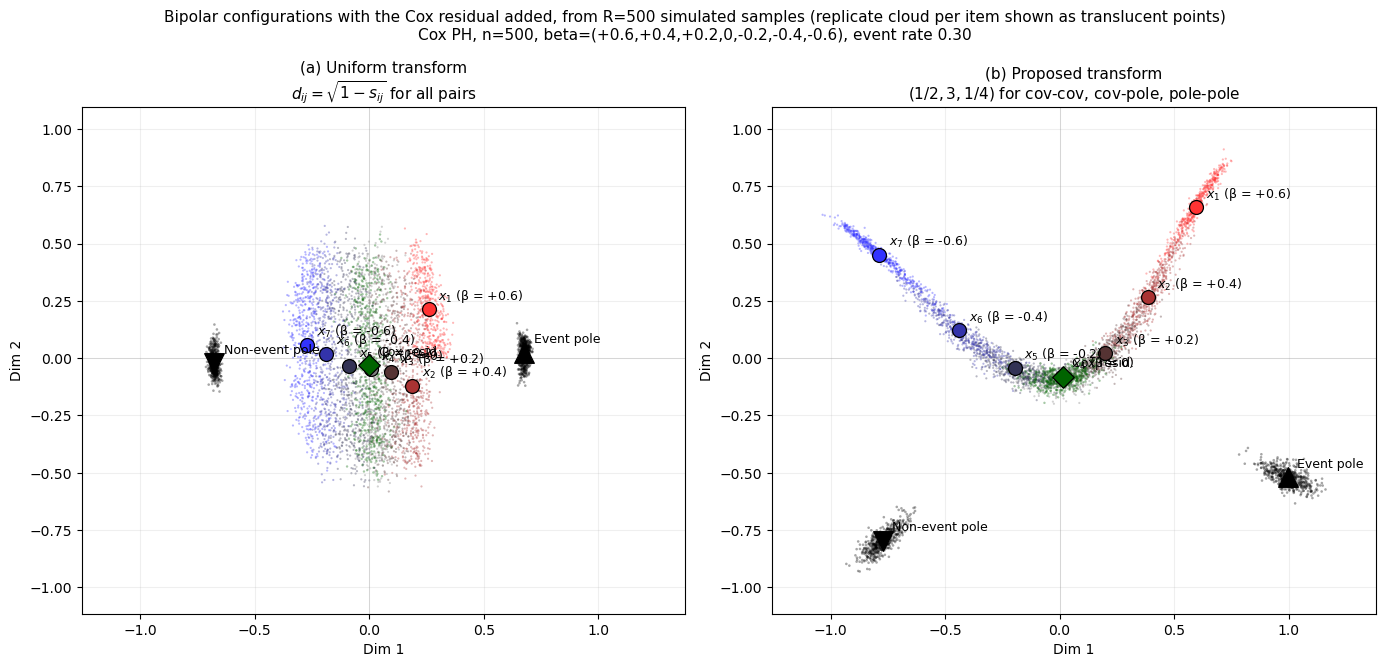


シミュレーション完了


In [6]:
# ============================================================
# 実行本体（2セル版）
# ============================================================
# このセルには、元 notebook の2セル目以降を順番どおりにまとめている。
# 計算ロジック・乱数 seed・出力処理は、可読性最大化版から変更しない。
# 「説明セル」は Python コメントとして残している。
# ============================================================


# ============================================================
# 元 notebook Cell 2
# ============================================================
# ------------------------------------------------------------
# 元 Markdown 説明セル（2セル版ではコメントとして保持）
# ------------------------------------------------------------
# # Paper 1 シミュレーション：sampling stability と距離変換の比較
#
# この notebook は、`SurvivalPoleMDS` クラスを使って、既知の Cox 比例ハザード生成過程から得た反復サンプルに対する配置の安定性を確認する。
#
# ## 読み方
#
# 1. **Cell 1**: `SurvivalPoleMDS` クラス定義。前回の改訂版クラスをそのまま使用する。
# 2. **Cell 2**: シミュレーションで使う補助関数。
# 3. **Cell 3**: すべての設定値を集約する。
# 4. **Cell 4**: `SurvivalPoleMDS` を呼び出す小関数と、診断用 Cox 回帰の小関数。
# 5. **Cell 5 以降**: キャリブレーション、シミュレーション本体、Procrustes 整列、数値サマリー、図の順に実行する。
#
# ## 数値を変えないための方針
#
# - 乱数 seed は従来どおり `seed=rep_idx` を使う。
# - proposed と uniform の計算順は従来どおり **proposed → uniform** とする。
# - `SurvivalPoleMDS` を proposed 用と uniform 用にそれぞれ作る構造を維持する。これは高速ではないが、可読性が高く、どの指数で計算したかが明確になる。
# - Closer pole 判定と centrality は、従来どおり **2次元 CMDS 座標上のユークリッド距離**で評価する。


# ============================================================
# 元 notebook Cell 3
# ============================================================
# ============================================================
# 補助関数: データ生成・キャリブレーション・Procrustes 整列
# ============================================================

import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt


def simulate_cox_weibull(n, beta, lambd, nu, tau, seed):
    """Cox PH + Weibull ベースラインで生存データを生成する.

    Bender, Augustin & Blettner (2005) の逆 CDF 法に従う.

    Parameters
    ----------
    n     : int
        サンプルサイズ.
    beta  : array-like, shape (p,)
        真の回帰係数.
    lambd : float
        Weibull scale パラメータ. 大きいほどイベントが早く起きる.
    nu    : float
        Weibull shape パラメータ. 1 なら exponential.
    tau   : float
        Type I 打ち切り時刻. 全員をこの時点で右側打ち切りにする.
    seed  : int
        乱数シード.

    Returns
    -------
    df : pandas.DataFrame
        列は x1, x2, ..., xp, time, event.
    """
    rng = np.random.default_rng(seed)
    beta = np.asarray(beta, dtype=float)
    p = len(beta)

    # 共変量: 独立標準正規 N(0, I_p)
    X = rng.standard_normal((n, p))

    # 逆 CDF 法:
    # S(t | x) = exp(-lambda * t^nu * exp(beta'x))
    # T = {-log(U) / [lambda * exp(beta'x)]}^{1/nu}
    U = rng.uniform(size=n)
    linear_pred = X @ beta
    numerator = -np.log(U)
    denominator = lambd * np.exp(linear_pred)
    T_latent = (numerator / denominator) ** (1.0 / nu)

    # Type I 右側打ち切り
    T_obs = np.minimum(T_latent, tau)
    event = (T_latent <= tau).astype(int)

    col_names = []
    for idx in range(p):
        col_names.append('x' + str(idx + 1))

    df = pd.DataFrame(X, columns=col_names)
    df['time'] = T_obs
    df['event'] = event
    return df


def calibrate_lambda(target_rate, beta, nu, tau, n=5000, tol=0.01,
                     max_iter=40, seed=0):
    """目標イベント率になる Weibull scale lambd を二分法で探索する.

    beta, nu, tau を固定したまま lambd だけを動かし、イベント率が
    target_rate に近くなる値を探す. lambd は全体のハザード水準なので、
    lambd が大きいほどイベント率は高くなる.
    """
    lambd_lo = 1e-6
    lambd_hi = 10.0

    for _ in range(max_iter):
        lambd_mid = 0.5 * (lambd_lo + lambd_hi)
        df_test = simulate_cox_weibull(
            n=n, beta=beta, lambd=lambd_mid, nu=nu, tau=tau, seed=seed
        )
        rate_mid = df_test['event'].mean()

        if abs(rate_mid - target_rate) < tol:
            return lambd_mid, rate_mid

        if rate_mid < target_rate:
            # イベント率が不足 -> ハザードを上げる（lambd を増やす）
            lambd_lo = lambd_mid
        else:
            # イベント率が過剰 -> ハザードを下げる（lambd を減らす）
            lambd_hi = lambd_mid

    return lambd_mid, rate_mid


def procrustes_align(reference, target):
    """target を reference に対して Procrustes 整列する.

    MDS の解は回転・反射・スケーリング・平行移動について不定なので、
    replicate 間で座標を比較する前に共通の基準に揃える.
    """
    ref_centered = reference - reference.mean(axis=0)
    tgt_centered = target - target.mean(axis=0)

    # 直交変換行列 R（回転 + 反射）を最小二乗で求める.
    R, _ = orthogonal_procrustes(tgt_centered, ref_centered)
    aligned = tgt_centered @ R

    # 参照配置とサイズ（Frobenius norm）を揃える.
    if np.linalg.norm(aligned) > 0:
        aligned = aligned * (np.linalg.norm(ref_centered) /
                             np.linalg.norm(aligned))
    return aligned


def print_section(title, subtitle=None):
    """notebook の実行ログを読みやすくするための見出し出力."""
    print()
    print("=" * 60)
    print(title)
    if subtitle is not None:
        print(subtitle)
    print("=" * 60)



# ============================================================
# 元 notebook Cell 4
# ============================================================
# ============================================================
# シミュレーション設定
# ============================================================
# ここに実験条件を集約しておくと、後から設定を変える場所が明確になる.

# 真の回帰係数: 双極的な構造
# x1-x3: イベントを促進する（正の効果）
# x4:    中立（効果なし）
# x5-x7: イベントを抑制する（負の効果）
BETA_TRUE = np.array([0.6, 0.4, 0.2, 0.0, -0.2, -0.4, -0.6])
COV_NAMES = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7']

N_SAMPLE = 500      # 1 サンプルあたりの個体数
N_REP = 500         # シミュレーション反復回数（R）
NU = 1.0            # Weibull shape: 1 なら定常ハザード
TAU = 10.0          # Type I 打ち切り時刻（全員 t=tau で検閲）
TARGET_RATE = 0.30  # 目標イベント率（Rossi の 26% 前後を想定）

# 実行ログ・図ファイル名
PROGRESS_EVERY = 50
FIGURE_FILENAME = 'p1_fig4_simulation.png'

# SurvivalPoleMDS の極ラベル
EVENT_POLE = 'Event'
NONEVENT_POLE = 'Non-event'
COX_RESID_NAME = 'Unexplained'

# full_bi のラベル順: 共変量 + Cox 残差 + 2 極
LABELS_FULL_BI = COV_NAMES + [COX_RESID_NAME, EVENT_POLE, NONEVENT_POLE]
N_ITEMS_FULL_BI = len(LABELS_FULL_BI)

# 距離変換指数
# proposed: 論文で使う提案変換
# uniform : すべてのペアに同じ平方根変換を使う比較基準
PROPOSED_EXPONENTS = {
    'cov_cov': 0.5,
    'cov_pole': 3.0,
    'pole_pole': 0.25,
}
UNIFORM_EXPONENTS = {
    'cov_cov': 0.5,
    'cov_pole': 0.5,
    'pole_pole': 0.5,
}

# 図中の表示名
DISPLAY_MAP = {
    'x1': r'$x_1$' + ' (β = +0.6)',
    'x2': r'$x_2$' + ' (β = +0.4)',
    'x3': r'$x_3$' + ' (β = +0.2)',
    'x4': r'$x_4$' + ' (β = 0)',
    'x5': r'$x_5$' + ' (β = -0.2)',
    'x6': r'$x_6$' + ' (β = -0.4)',
    'x7': r'$x_7$' + ' (β = -0.6)',
    COX_RESID_NAME: 'Cox resid.',
    EVENT_POLE: 'Event pole',
    NONEVENT_POLE: 'Non-event pole',
}

# よく使うインデックスを先に取っておく.
IDX_REC = LABELS_FULL_BI.index(EVENT_POLE)
IDX_NON = LABELS_FULL_BI.index(NONEVENT_POLE)
IDX_COX = LABELS_FULL_BI.index(COX_RESID_NAME)
IDX_X1 = LABELS_FULL_BI.index('x1')



# ============================================================
# 元 notebook Cell 5
# ============================================================
# ============================================================
# SurvivalPoleMDS を呼び出す小関数・診断用 Cox 回帰
# ============================================================

def compute_full_bi_coords(df_sim, exponents, transform_label, rep_idx):
    """1 つの replicate から full_bi 座標を計算する.

    可読性重視のため、proposed と uniform ではそれぞれ
    SurvivalPoleMDS インスタンスを作る. 同じ残差計算を2回行うため
    速度面では冗長だが、どの指数で計算したかが非常に明確になる.

    try-except の目的:
    MDS 配置はシミュレーション本体なので、失敗を黙って NaN にしない.
    どの replicate のどの変換条件で落ちたかを明示して停止する.
    """
    try:
        spm = SurvivalPoleMDS(
            df=df_sim,
            covariates=COV_NAMES,
            time_col='time',
            event_col='event',
            tau=TAU,
            event_pole=EVENT_POLE,
            nonevent_pole=NONEVENT_POLE,
            cox_resid_name=COX_RESID_NAME,
            dataset_name='Simulation',
            display_names=None,
            **exponents,
        )
        spm.fit_configuration('full_bi', LABELS_FULL_BI)
        return spm.configs['full_bi']['coords']

    except Exception as exc:
        message = (
            f"full_bi coordinate computation failed at replicate {rep_idx} "
            f"under the {transform_label} transform."
        )
        raise RuntimeError(message) from exc


def fit_cox_for_diagnostics(df_sim, rep_idx):
    """診断用 Cox 回帰を当てはめ、係数推定値を返す.

    try-except の目的:
    この Cox 回帰は「生成データが真の beta を回収できるか」を見る
    診断表用であり、MDS 配置そのものの入力ではない. まれな収束失敗で
    シミュレーション全体を止めると、主目的である配置安定性の確認が
    進まない. そのため失敗時は NaN と失敗情報を返す.

    Returns
    -------
    beta_hat : numpy.ndarray, shape (p,)
        Cox 係数推定値. 失敗時は全要素 NaN.
    failure_info : None or tuple
        成功時は None. 失敗時は (rep_idx, error_repr).
    """
    try:
        cph_sim = CoxPHFitter()
        cph_sim.fit(df_sim, duration_col='time', event_col='event',
                    show_progress=False)
        return cph_sim.params_.values, None
    except Exception as exc:
        return np.full(len(BETA_TRUE), np.nan), (rep_idx, repr(exc))



# ============================================================
# 元 notebook Cell 6
# ============================================================
# ============================================================
# Step 1: lambda のキャリブレーション
# ============================================================
# 目標イベント率 TARGET_RATE に合う Weibull scale lambd を探索する.
# ここで得た lambd は、以降の全 replicate で固定して使う.

print_section(
    "Step 1: Weibull scale lambd のキャリブレーション",
    "        （目標イベント率 {:.0%} に合わせて lambd を探索）".format(TARGET_RATE)
)

lambd_cal, rate_cal = calibrate_lambda(
    target_rate=TARGET_RATE, beta=BETA_TRUE, nu=NU, tau=TAU,
    n=5000, seed=0
)

print(f"  得られた lambd = {lambd_cal:.4f}")
print(f"  キャリブレーション時のイベント率 = {rate_cal:.3f}")
print("  （以降のシミュレーションはこの lambd を固定値として使う）")



# ============================================================
# 元 notebook Cell 7
# ============================================================
# ============================================================
# Step 2: シミュレーションループ
# ============================================================
# 各 replicate で、サンプル生成 -> Cox 診断 -> proposed配置 -> uniform配置
# の順に実行する. この順序は旧版と同じなので、乱数列と主要出力が変わらない.

print_section(
    f"Step 2: シミュレーションループ実行（R = {N_REP} 回繰り返し）",
    f"        各 replicate で n = {N_SAMPLE} 人を生成し、proposed と uniform の full_bi 配置を計算"
)

# 格納用配列
# shape (R, 10, 2)  10 = 7 共変量 + Cox 残差 + Event 極 + Non-event 極
coords_proposed = np.zeros((N_REP, N_ITEMS_FULL_BI, 2))
coords_uniform = np.zeros((N_REP, N_ITEMS_FULL_BI, 2))

event_rates = np.zeros(N_REP)
cox_estimates = np.full((N_REP, len(BETA_TRUE)), np.nan)
cox_fit_failures = []

for rep_idx in range(N_REP):
    # (a) サンプル生成
    # seed=rep_idx と固定することで、旧版と同じ replicate 列を再現する.
    df_sim = simulate_cox_weibull(
        n=N_SAMPLE, beta=BETA_TRUE, lambd=lambd_cal,
        nu=NU, tau=TAU, seed=rep_idx
    )
    event_rates[rep_idx] = df_sim['event'].mean()

    # (b) Cox 回帰で beta の回収を記録（診断用）
    beta_hat, failure_info = fit_cox_for_diagnostics(df_sim, rep_idx)
    cox_estimates[rep_idx] = beta_hat
    if failure_info is not None:
        cox_fit_failures.append(failure_info)

    # (c) 提案変換: 論文の距離変換指数 (0.5, 3.0, 0.25)
    coords_proposed[rep_idx] = compute_full_bi_coords(
        df_sim=df_sim,
        exponents=PROPOSED_EXPONENTS,
        transform_label='proposed',
        rep_idx=rep_idx,
    )

    # (d) uniform 変換: すべてのペアで指数 0.5 を使う比較基準
    coords_uniform[rep_idx] = compute_full_bi_coords(
        df_sim=df_sim,
        exponents=UNIFORM_EXPONENTS,
        transform_label='uniform',
        rep_idx=rep_idx,
    )

    # 進捗表示
    if (rep_idx + 1) % PROGRESS_EVERY == 0:
        print(f"  {rep_idx + 1} / {N_REP} replicates 完了")

print()
print(f"  平均イベント率: {event_rates.mean():.3f}  "
      f"(SD {event_rates.std():.3f})")

if len(cox_fit_failures) == 0:
    print("  Cox 回帰診断の収束失敗: 0 回")
else:
    print(f"  Cox 回帰診断の収束失敗: {len(cox_fit_failures)} 回")
    print("  失敗 replicate は Cox 係数回収表では NaN として扱う.")
    print("  最初の失敗例:", cox_fit_failures[0])



# ============================================================
# 元 notebook Cell 8
# ============================================================
# ============================================================
# Step 3: Procrustes 整列と向きの統一
# ============================================================
# まず最初の replicate を基準に Procrustes 整列し、その後、
# 極と x1 の位置を使って軸の向きを統一する.

print_section(
    "Step 3: Procrustes 整列（最初の replicate を基準配置に）",
    "        MDS の回転・反射・スケール不定性を除去して比較可能にする"
)

aligned_proposed = np.zeros_like(coords_proposed)
aligned_uniform = np.zeros_like(coords_uniform)

ref_prop = coords_proposed[0]
ref_unif = coords_uniform[0]
aligned_proposed[0] = ref_prop - ref_prop.mean(axis=0)
aligned_uniform[0] = ref_unif - ref_unif.mean(axis=0)

for r_idx in range(1, N_REP):
    aligned_proposed[r_idx] = procrustes_align(
        aligned_proposed[0], coords_proposed[r_idx]
    )
    aligned_uniform[r_idx] = procrustes_align(
        aligned_uniform[0], coords_uniform[r_idx]
    )

print("  Procrustes 整列完了")


print_section(
    "Step 3b: 向きの統一（Procrustes の反射不定性を除去）"
)

flip_x_prop = 0
flip_y_prop = 0
flip_x_unif = 0
flip_y_unif = 0

for r_idx in range(N_REP):
    # (1) Dim 1: Event pole が Non-event pole より右に来るようにする.
    if aligned_proposed[r_idx][IDX_REC][0] < aligned_proposed[r_idx][IDX_NON][0]:
        aligned_proposed[r_idx][:, 0] = -aligned_proposed[r_idx][:, 0]
        flip_x_prop = flip_x_prop + 1

    if aligned_uniform[r_idx][IDX_REC][0] < aligned_uniform[r_idx][IDX_NON][0]:
        aligned_uniform[r_idx][:, 0] = -aligned_uniform[r_idx][:, 0]
        flip_x_unif = flip_x_unif + 1

    # (2) Dim 2: x1 が y > 0 側に来るようにする.
    if aligned_proposed[r_idx][IDX_X1][1] < 0:
        aligned_proposed[r_idx][:, 1] = -aligned_proposed[r_idx][:, 1]
        flip_y_prop = flip_y_prop + 1

    if aligned_uniform[r_idx][IDX_X1][1] < 0:
        aligned_uniform[r_idx][:, 1] = -aligned_uniform[r_idx][:, 1]
        flip_y_unif = flip_y_unif + 1

print(f"  提案変換:  Dim 1 反転 {flip_x_prop}/{N_REP} 回, Dim 2 反転 {flip_y_prop}/{N_REP} 回")
print(f"  Uniform:   Dim 1 反転 {flip_x_unif}/{N_REP} 回, Dim 2 反転 {flip_y_unif}/{N_REP} 回")
print("  向きの統一完了")



# ============================================================
# 元 notebook Cell 9
# ============================================================
# ============================================================
# Step 4: 数値サマリー
# ============================================================
# (i) Cox 係数の回収
# (ii) Closer pole 分類の一貫性
# (iii) Cox 残差の centrality

print_section("Step 4: 数値サマリー")

# ------------------------------------------------------------
# (i) Cox 係数の回収
# ------------------------------------------------------------
print()
print("(i) Cox 回帰による beta の回収（R 回の平均 ± SD）:")

cox_mean = np.nanmean(cox_estimates, axis=0)
cox_sd = np.nanstd(cox_estimates, axis=0)
recovery_table = pd.DataFrame({
    'true_beta': BETA_TRUE,
    'mean_hat': cox_mean,
    'sd_hat': cox_sd,
}, index=COV_NAMES)

print(recovery_table.round(3))
print()
print("  → mean_hat が true_beta に近いほどデータ生成過程が意図通り.")


# ------------------------------------------------------------
# (ii) Closer pole 分類の一貫性
# ------------------------------------------------------------
print()
print("(ii) Closer pole 分類の一貫性:")
print("     各共変量が R 回の配置のうち何割で Event pole 側に分類されたか")
print("     判定は 2次元 CMDS 座標上の距離で行う.")

rec_side_counts_prop = np.zeros(len(COV_NAMES), dtype=int)
rec_side_counts_unif = np.zeros(len(COV_NAMES), dtype=int)

for r_idx in range(N_REP):
    coords_p = coords_proposed[r_idx]
    coords_u = coords_uniform[r_idx]

    for cov_idx in range(len(COV_NAMES)):
        d_rec_p = np.linalg.norm(coords_p[cov_idx] - coords_p[IDX_REC])
        d_non_p = np.linalg.norm(coords_p[cov_idx] - coords_p[IDX_NON])
        if d_rec_p < d_non_p:
            rec_side_counts_prop[cov_idx] += 1

        d_rec_u = np.linalg.norm(coords_u[cov_idx] - coords_u[IDX_REC])
        d_non_u = np.linalg.norm(coords_u[cov_idx] - coords_u[IDX_NON])
        if d_rec_u < d_non_u:
            rec_side_counts_unif[cov_idx] += 1

closer_pole_table = pd.DataFrame({
    'true_beta': BETA_TRUE,
    'P(Event側) [proposed]': rec_side_counts_prop / N_REP,
    'P(Event側) [uniform]': rec_side_counts_unif / N_REP,
}, index=COV_NAMES)

print()
print(closer_pole_table.round(3))
print()
print("  → 真の beta が正の変数 (x1,x2,x3) では P(Event側) が 1 に近く、")
print("     負の変数 (x5,x6,x7) では 0 に近いのが期待される.")


# ------------------------------------------------------------
# (iii) Cox 残差の centrality
# ------------------------------------------------------------
# ここでも距離は 2 次元 CMDS 配置上のユークリッド距離である.
# proposed だけでなく uniform も出し、比較条件として対称に扱う.
cox_ratio_prop = np.zeros(N_REP)
cox_ratio_unif = np.zeros(N_REP)

for r_idx in range(N_REP):
    coords_p = coords_proposed[r_idx]
    d_rec_p = np.linalg.norm(coords_p[IDX_COX] - coords_p[IDX_REC])
    d_non_p = np.linalg.norm(coords_p[IDX_COX] - coords_p[IDX_NON])
    cox_ratio_prop[r_idx] = d_rec_p / d_non_p if d_non_p > 0 else np.nan

    coords_u = coords_uniform[r_idx]
    d_rec_u = np.linalg.norm(coords_u[IDX_COX] - coords_u[IDX_REC])
    d_non_u = np.linalg.norm(coords_u[IDX_COX] - coords_u[IDX_NON])
    cox_ratio_unif[r_idx] = d_rec_u / d_non_u if d_non_u > 0 else np.nan

centrality_table = pd.DataFrame({
    'median': [np.nanmedian(cox_ratio_prop), np.nanmedian(cox_ratio_unif)],
    'q25': [np.nanpercentile(cox_ratio_prop, 25),
            np.nanpercentile(cox_ratio_unif, 25)],
    'q75': [np.nanpercentile(cox_ratio_prop, 75),
            np.nanpercentile(cox_ratio_unif, 75)],
}, index=['proposed', 'uniform'])

print()
print("(iii) Cox 残差の centrality 指標 d(Event極) / d(Non-event極):")
print(centrality_table.round(3))
print()
print("  → 1 に近ければ Cox 残差が両極から等距離（中央付近）を意味する.")
print("     データが Cox PH に従って生成されたので、Cox 残差は")
print("     outcome 方向の情報を持たず中央に留まることが期待される.")



# ============================================================
# 元 notebook Cell 10
# ============================================================
# ============================================================
# Step 5: 可視化 Figure 4: 平均配置 + replicate クラウド
# ============================================================
# 2 パネル構成で uniform 変換と proposed 変換を比較する.
# 点群そのものを薄く描くことで、楕円近似に頼らず分布形状を見せる.

print_section(
    "Step 5: 可視化（Figure 4）",
    "        replicate クラウド + 平均配置を左右 2 パネルで比較"
)


def item_style(label):
    """ラベルごとのスタイル（color, marker, size）を返す."""
    if label == EVENT_POLE:
        return {'color': 'black', 'marker': '^', 's_mean': 200,
                's_cloud': 14, 'zorder': 5}

    if label == NONEVENT_POLE:
        return {'color': 'black', 'marker': 'v', 's_mean': 200,
                's_cloud': 14, 'zorder': 5}

    if label == COX_RESID_NAME:
        return {'color': 'darkgreen', 'marker': 'D', 's_mean': 120,
                's_cloud': 12, 'zorder': 4}

    # 共変量: 係数の符号と強さで色を決める.
    idx = COV_NAMES.index(label)
    b = BETA_TRUE[idx]

    if b > 0.01:
        intensity = min(1.0, abs(b) / 0.6)
        return {'color': (intensity, 0.2, 0.2), 'marker': 'o',
                's_mean': 100, 's_cloud': 10, 'zorder': 3}

    if b < -0.01:
        intensity = min(1.0, abs(b) / 0.6)
        return {'color': (0.2, 0.2, intensity), 'marker': 'o',
                's_mean': 100, 's_cloud': 10, 'zorder': 3}

    return {'color': 'gray', 'marker': 'o',
            's_mean': 100, 's_cloud': 10, 'zorder': 3}


fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

panel_data = [
    (aligned_uniform, 'Uniform transform',
     r'$d_{ij}=\sqrt{1-s_{ij}}$ for all pairs'),
    (aligned_proposed, 'Proposed transform',
     r'$(1/2, 3, 1/4)$ for cov-cov, cov-pole, pole-pole'),
]

for ax_idx in range(2):
    ax = axes[ax_idx]
    aligned_array, title, subtitle = panel_data[ax_idx]

    # (1) N_REP 個の replicate クラウドを薄く散布する.
    for item_idx in range(N_ITEMS_FULL_BI):
        label = LABELS_FULL_BI[item_idx]
        pts = aligned_array[:, item_idx, :]  # shape (R, 2)
        style = item_style(label)
        ax.scatter(pts[:, 0], pts[:, 1],
                   color=style['color'], marker='.',
                   s=style['s_cloud'], alpha=0.35,
                   edgecolors='none',
                   zorder=style['zorder'] - 2)

    # (2) 平均位置のマーカーとラベルを重ねる.
    for item_idx in range(N_ITEMS_FULL_BI):
        label = LABELS_FULL_BI[item_idx]
        pts = aligned_array[:, item_idx, :]
        center = pts.mean(axis=0)
        style = item_style(label)

        ax.scatter(center[0], center[1], color=style['color'],
                   marker=style['marker'], s=style['s_mean'],
                   edgecolors='black', linewidths=0.9,
                   zorder=style['zorder'])
        ax.annotate(DISPLAY_MAP.get(label, label),
                    xy=center, xytext=(7, 7), textcoords='offset points',
                    fontsize=9, zorder=style['zorder'] + 1)

    panel_title = '(' + chr(97 + ax_idx) + ') ' + title + chr(10) + subtitle
    ax.set_title(panel_title, fontsize=11)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.axhline(0, color='gray', linewidth=0.4, alpha=0.4)
    ax.axvline(0, color='gray', linewidth=0.4, alpha=0.4)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

# 両パネルで軸範囲を統一する.
all_xs = []
all_ys = []
for aligned_array, _, _ in panel_data:
    all_xs.append(aligned_array[:, :, 0].flatten())
    all_ys.append(aligned_array[:, :, 1].flatten())

x_all = np.concatenate(all_xs)
y_all = np.concatenate(all_ys)
x_margin = 0.1 * (x_all.max() - x_all.min())
y_margin = 0.1 * (y_all.max() - y_all.min())
common_xlim = (x_all.min() - x_margin, x_all.max() + x_margin)
common_ylim = (y_all.min() - y_margin, y_all.max() + y_margin)

for ax in axes:
    ax.set_xlim(common_xlim)
    ax.set_ylim(common_ylim)

suptitle_line1 = ('Bipolar configurations with the Cox residual added, from R=' +
                  str(N_REP) + ' simulated samples '
                  '(replicate cloud per item shown as translucent points)')
suptitle_line2 = ('Cox PH, n=' + str(N_SAMPLE) +
                  ', beta=(+0.6,+0.4,+0.2,0,-0.2,-0.4,-0.6), '
                  'event rate ' + f'{event_rates.mean():.2f}')
plt.suptitle(suptitle_line1 + chr(10) + suptitle_line2,
             fontsize=11, y=1.00)

plt.tight_layout()
plt.savefig(FIGURE_FILENAME, dpi=200, bbox_inches='tight')
print(f"  保存: {FIGURE_FILENAME}")
plt.show()

print_section("シミュレーション完了")

